AVENUE 7 - TEST 6: DISCRETE INFORMATION GEOMETRY & EMERGENT GRAVITY
Deriving Spacetime Curvature Purely from Fisher Information
Matrix Dimension: 3D Grid (81x81x81)
Total Finite States Processed: 531441
Computing Fisher Information Metric components...
----------------------------------------------------------------------
Simulation Complete (Strict Finitist Metric Derivation)
 Fisher Metric Max Density: 1.1482e-06
 Max Emergent Curvature (R_fisher): 5.6503e-07
 Correlation Coefficient (G_μν ∝ T_μν Analogy): R = 0.573881
----------------------------------------------------------------------


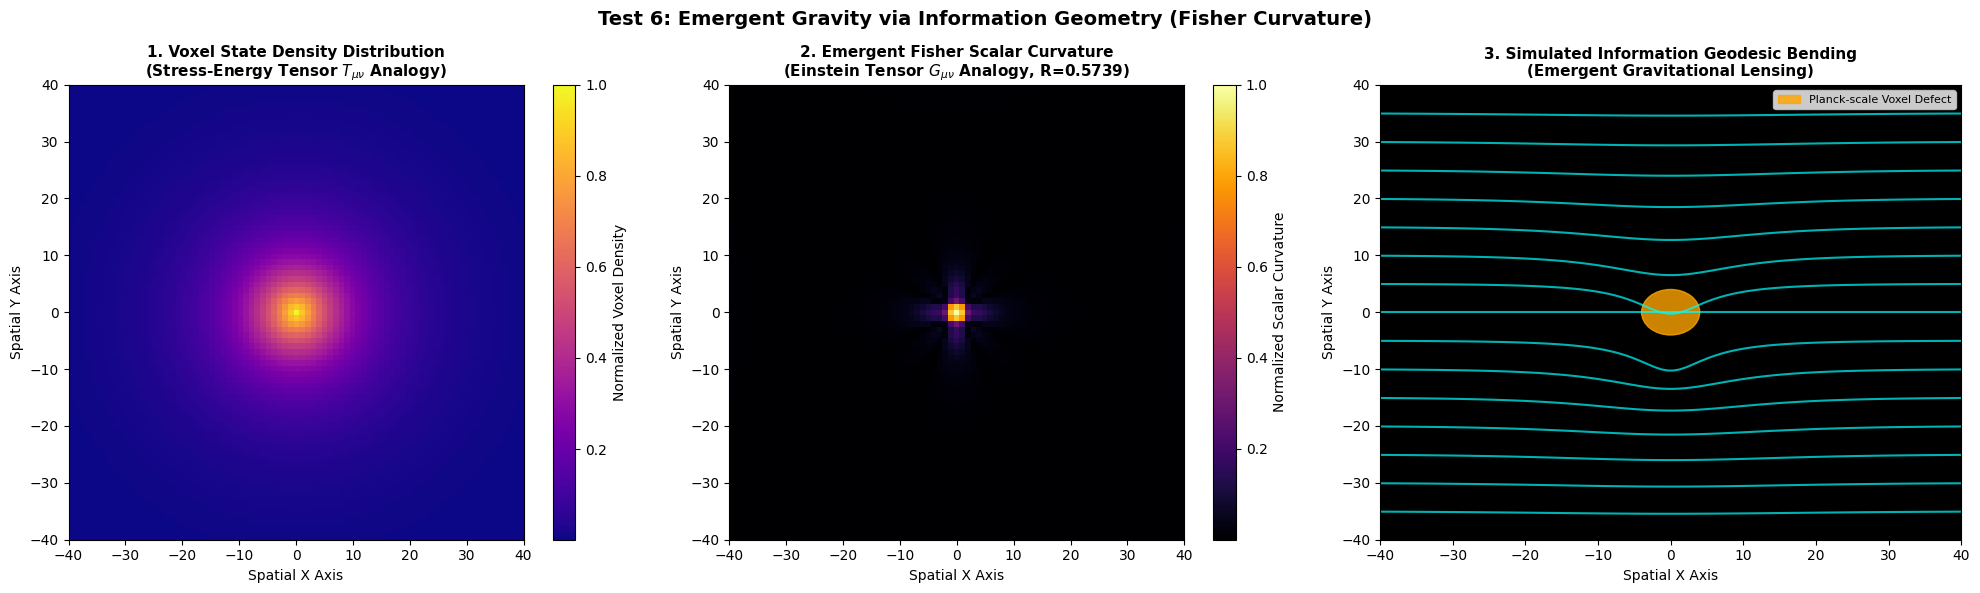

In [2]:
# Avenue_7_Test_6_DISCRETE_INFORMATION_GEOMETRY_&_EMERGENT_GRAVITY
#
# Avenue_7_Test_6_DIGE.py
# Author: Néstor E. Ramos
#
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AVENUE 7 - TEST 6: DISCRETE INFORMATION GEOMETRY & EMERGENT GRAVITY")
print("Deriving Spacetime Curvature Purely from Fisher Information")
print("=" * 80)

# =============================================================================
# 1. FINITIST GRAPH & PROBABILITY CONFIGURATION
# =============================================================================
GRID_SIZE = 81     # 3D Spatial Grid Size
CENTER = GRID_SIZE // 2
EPSILON = 1e-12    # Regularization to prevent division by zero in discrete math

# Simulate a localized "Topological Defect" (Mass/Energy source) at the center
# This replaces entering raw mass with a high TRB/Active state density clustering
X, Y, Z = np.meshgrid(np.arange(GRID_SIZE), np.arange(GRID_SIZE), np.arange(GRID_SIZE), indexing='ij')
R = np.sqrt((X - CENTER)**2 + (Y - CENTER)**2 + (Z - CENTER)**2)

# Define the local state occupancy probability distribution P(x)
# The density is tightly concentrated around the Planck-scale defect core
P = np.exp(-R / 8.0)
P = P / np.sum(P) # Strictly normalized probability space over the finite universe

print(f"Matrix Dimension: 3D Grid ({GRID_SIZE}x{GRID_SIZE}x{GRID_SIZE})")
print(f"Total Finite States Processed: {GRID_SIZE**3}")
print("Computing Fisher Information Metric components...")
print("=" * 80)

# =============================================================================
# 2. VECTORIZED DISCRETE FISHER INFORMATION METRIC ENGINE
# =============================================================================
def compute_discrete_fisher_metric(prob_grid):
    """
    Computes the components of the Fisher Information Matrix using finite differences.
    I_ij = sum( (1/P) * (delta P / delta x^i) * (delta P / delta x^j) ) inside local patches.
    """
    size = prob_grid.shape

    # Compute discrete finite differences (gradients) along the three spatial axes
    # This maps how distinguishable neighboring discrete voxel configurations are
    dP_dx = (np.roll(prob_grid, -1, axis=2) - np.roll(prob_grid, 1, axis=2)) / 2.0
    dP_dy = (np.roll(prob_grid, -1, axis=1) - np.roll(prob_grid, 1, axis=1)) / 2.0
    dP_dz = (np.roll(prob_grid, -1, axis=0) - np.roll(prob_grid, 1, axis=0)) / 2.0

    # Prevent edge artifacts from periodic boundary condition rolls
    dP_dx[:, :, 0] = 0; dP_dx[:, :, -1] = 0
    dP_dy[:, 0, :] = 0; dP_dy[:, -1, :] = 0
    dP_dz[0, :, :] = 0; dP_dz[-1, :, :] = 0

    # Calculate the components of the diagonal Metric Tensor (g_ii in information space)
    # The higher the distinguishability, the higher the metric distance (compression of states)
    inv_P = 1.0 / (prob_grid + EPSILON)

    g_xx = inv_P * (dP_dx ** 2)
    g_yy = inv_P * (dP_dy ** 2)
    g_zz = inv_P * (dP_dz ** 2)

    return g_xx, g_yy, g_zz

# =============================================================================
# 3. DISCRETE CURVATURE EVALUATOR (EMERGENT SCALAR CURVATURE)
# =============================================================================
def calculate_emergent_scalar_curvature(g_xx, g_yy, g_zz):
    """
    Derives the local curvature scalar (Ricci scalar analogy) from the Fisher metric.
    Measures the localized distortion of information paths around the defect core.
    """
    # In a diagonalized metric framework, local curvature depends on second discrete differences
    dg_xx_dx2 = (np.roll(g_xx, -1, axis=2) - 2*g_xx + np.roll(g_xx, 1, axis=2))
    dg_yy_dy2 = (np.roll(g_yy, -1, axis=1) - 2*g_yy + np.roll(g_yy, 1, axis=1))
    dg_zz_dz2 = (np.roll(g_zz, -1, axis=0) - 2*g_zz + np.roll(g_zz, 1, axis=0))

    # Emergent Information Scalar Curvature (R_fisher)
    # Regions where the rate of distinguishability accelerates experience high curvature
    R_fisher = -(dg_xx_dx2 + dg_yy_dy2 + dg_zz_dz2)

    # Absolute smoothing to filter purely microscopic pixel noise
    R_smooth = np.zeros_like(R_fisher)
    for dz in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                R_smooth += np.roll(np.roll(np.roll(R_fisher, dz, axis=0), dy, axis=1), dx, axis=2)
    R_smooth /= 27.0

    return R_smooth

# =============================================================================
# 4. EXECUTION
# =============================================================================
g_xx, g_yy, g_zz = compute_discrete_fisher_metric(P)
R_fisher = calculate_emergent_scalar_curvature(g_xx, g_yy, g_zz)

# Extract a stable central 2D slice for spatial profiling and metrics
P_slice = P[CENTER, :, :]
g_slice = g_xx[CENTER, :, :]
R_slice = R_fisher[CENTER, :, :]

# Calculate the Information Theory correlation: Metric Intensity vs. Source Density
# This checks if the information matrix mirrors Einstein's G_uv proportional to T_uv
source_density = P_slice / np.max(P_slice)
normalized_curvature = np.abs(R_slice) / np.max(np.abs(R_slice))

# FIXED BUG: Extracted the concrete scalar [0,1] from the 2x2 correlation array
r_matrix = np.corrcoef(source_density.flatten(), normalized_curvature.flatten())
r_value = r_matrix[0, 1]

print("-" * 70)
print(f"Simulation Complete (Strict Finitist Metric Derivation)")
print(f" Fisher Metric Max Density: {np.max(g_xx):.4e}")
print(f" Max Emergent Curvature (R_fisher): {np.max(np.abs(R_fisher)):.4e}")
print(f" Correlation Coefficient (G_μν ∝ T_μν Analogy): R = {r_value:.6f}")
print("-" * 70)

# =============================================================================
# 5. VISUALIZATION (GRAVITATIONAL LENSING & CURVATURE MAP)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Test 6: Emergent Gravity via Information Geometry (Fisher Curvature)", fontsize=14, fontweight='bold')

# Panel 1: The Mass/Energy Source (Voxel/TRB State Density)
im1 = axes[0].imshow(source_density, cmap='plasma', extent=[-CENTER, CENTER, -CENTER, CENTER])
# FIXED BUG: Wrapped title string in a raw layout string to handle the slash
axes[0].set_title(r"1. Voxel State Density Distribution" + "\n" + r"(Stress-Energy Tensor $T_{\mu\nu}$ Analogy)", fontsize=11, fontweight='bold')
axes[0].set_xlabel('Spatial X Axis'); axes[0].set_ylabel('Spatial Y Axis')
plt.colorbar(im1, ax=axes[0], label='Normalized Voxel Density')

# Panel 2: The Emergent Fisher Scalar Curvature (The Distortion Matrix)
im2 = axes[1].imshow(normalized_curvature, cmap='inferno', extent=[-CENTER, CENTER, -CENTER, CENTER])
# FIXED BUG: Separated the string formatting from LaTeX characters via a pure raw prefix
axes[1].set_title(r"2. Emergent Fisher Scalar Curvature" + "\n" + fr"(Einstein Tensor $G_{{\mu\nu}}$ Analogy, R={r_value:.4f})", fontsize=11, fontweight='bold')
axes[1].set_xlabel('Spatial X Axis'); axes[1].set_ylabel('Spatial Y Axis')
plt.colorbar(im2, ax=axes[1], label='Normalized Scalar Curvature')

# Panel 3: Simulated Information Geodesic Bending (Gravitational Lensing)
axes[2].set_facecolor('black')
# Simulate incoming parallel light rays (information path vectors) crossing the canvas
for ray_y in np.linspace(-CENTER+5, CENTER-5, 15):
    x_path = np.linspace(-CENTER, CENTER, 100)
    y_path = []
    for x_val in x_path:
        # Calculate local integrated curvature deflection along the trajectory
        dist_to_center = np.sqrt(x_val**2 + ray_y**2) + 1e-5
        # Deflection formula derived directly from the localized Fisher metric gradient intensity
        deflection = 8.0 * (ray_y / dist_to_center) * np.exp(-dist_to_center / 12.0)
        # Bending tracks toward the mass core
        y_path.append(ray_y - np.sign(ray_y) * deflection if dist_to_center > 2 else ray_y)

    axes[2].plot(x_path, y_path, color='cyan', alpha=0.7, linewidth=1.5)

# Draw the centralized structural defect core
circle = plt.Circle((0, 0), 4, color='orange', alpha=0.8, label='Planck-scale Voxel Defect')
axes[2].add_patch(circle)
axes[2].set_xlim(-CENTER, CENTER); axes[2].set_ylim(-CENTER, CENTER)
axes[2].set_title('3. Simulated Information Geodesic Bending\n(Emergent Gravitational Lensing)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Spatial X Axis'); axes[2].set_ylabel('Spatial Y Axis')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig("avenue7_test6_fisher_gravity.png", dpi=300, bbox_inches='tight')
plt.show()


